# Notebook 2 - Evaluation & Analysis

Quantitative and qualitative evaluation of the multi-agent pipeline against ground-truth labels.

Prerequisite: run `python scripts/run_batch.py --n 100` first to produce `results/results.csv`.

In [15]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from src.config import RESULTS_DIR

RESULTS_PATH = RESULTS_DIR / 'results.csv'
df = pd.read_csv(RESULTS_PATH)
print('Rows:', len(df))
df.head()

Rows: 10


,article_id,title,true_label,label,confidence,summary,tone,bias_score,claims,fact_check,bias,elapsed_s,error
0,28641,Ex-Christie associates lose bid for new trial ...,REAL,REAL,0.97,Both claims are supported by credible news sou...,neutral,0.15,"{""claims"":[""U.S. District Judge Susan Wigenton...","{""results"":[{""claim"":""U.S. District Judge Susa...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",30.56,NaN
1,11994,BREAKING: OBAMACARE REPEAL Clears First Hurdle...,FAKE,FAKE,0.95,Two of three claims were directly contradicted...,sensationalist,0.85,"{""claims"":[""The Senate voted 51-48 this aftern...","{""results"":[{""claim"":""The Senate voted 51-48 t...","{""tone"":""sensationalist"",""bias_score"":0.85,""fl...",26.09,NaN
2,41618,Europe rights watchdog says Turkey's emergency...,REAL,FAKE,0.78,Two of the three claims were contradicted by e...,neutral,0.15,"{""claims"":[""An advisory body to the Council of...","{""results"":[{""claim"":""An advisory body to the ...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",22.00,NaN
3,13474,ABOUT HILLARY’S COUGH: We Discovered The Secre...,FAKE,REAL,0.78,The claim is supported by evidence from DuckDu...,neutral,0.15,"{""claims"":[""[Video] is a link that directs rea...","{""results"":[{""claim"":""[Video] is a link that d...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",14.34,NaN
4,26357,"At G20 summit, Trump pledges $639 million in a...",REAL,REAL,0.93,All three claims were supported by credible so...,neutral,0.15,"{""claims"":[""U.S. President Donald Trump on Sat...","{""results"":[{""claim"":""U.S. President Donald Tr...","{""tone"":""neutral"",""bias_score"":0.15,""flags"":[]}",28.93,NaN


In [16]:
eval_df = df.dropna(subset=['label', 'true_label']).copy()
eval_df = eval_df[eval_df['label'].isin(['REAL', 'FAKE'])]
print(f'Evaluable rows: {len(eval_df)} / {len(df)}')
print('\nPredicted distribution:')
print(eval_df['label'].value_counts())
print('\nTrue distribution:')
print(eval_df['true_label'].value_counts())

Evaluable rows: 10 / 10

Predicted distribution:
label
REAL    5
FAKE    5
Name: count, dtype: int64

True distribution:
true_label
REAL    5
FAKE    5
Name: count, dtype: int64


## 1. Classification report

In [17]:
y_true = eval_df['true_label'].tolist()
y_pred = eval_df['label'].tolist()
print(classification_report(y_true, y_pred, labels=['REAL', 'FAKE'], digits=3))

acc = (np.array(y_true) == np.array(y_pred)).mean()
print(f'Overall accuracy: {acc:.3f}')

              precision    recall  f1-score   support

        REAL      0.800     0.800     0.800         5
        FAKE      0.800     0.800     0.800         5

    accuracy                          0.800        10
   macro avg      0.800     0.800     0.800        10
weighted avg      0.800     0.800     0.800        10

Overall accuracy: 0.800


## 2. Confusion matrix

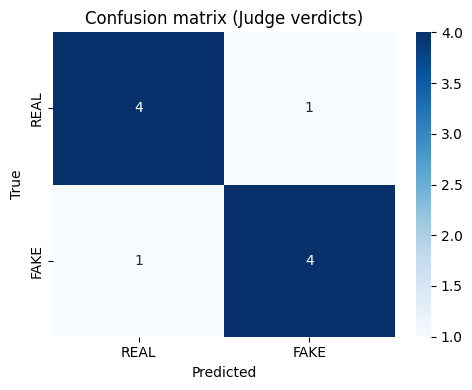

In [18]:
labels = ['REAL', 'FAKE']
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix (Judge verdicts)')
plt.tight_layout()
plt.show()

## 3. Confidence calibration

/var/folders/k_/ycd82fl13vv19qbljlfsjrvm0000gn/T/ipykernel_42887/69598772.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Wrong', 'Correct'])


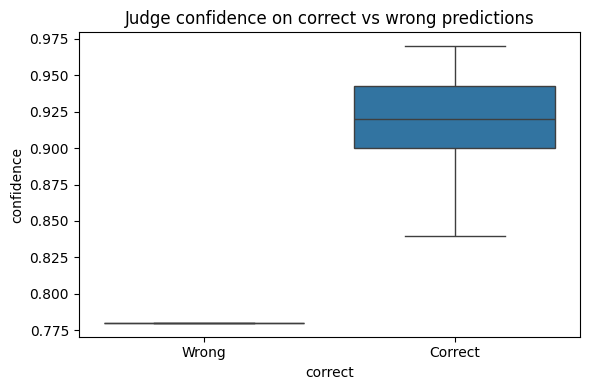

In [19]:
eval_df['correct'] = (eval_df['label'] == eval_df['true_label']).astype(int)
eval_df['confidence'] = pd.to_numeric(eval_df['confidence'], errors='coerce')

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='correct', y='confidence', data=eval_df, ax=ax)
ax.set_xticklabels(['Wrong', 'Correct'])
ax.set_title('Judge confidence on correct vs wrong predictions')
plt.tight_layout()
plt.show()

## 4. Bias score vs outcome

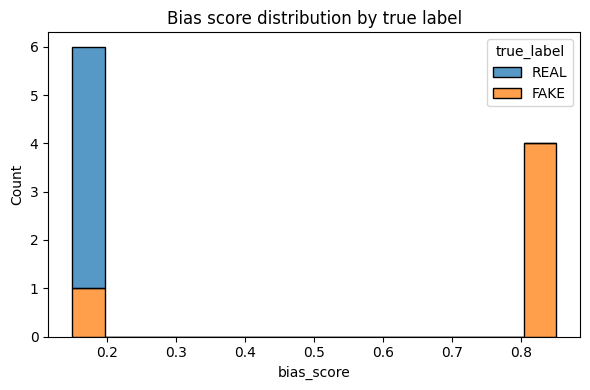

In [20]:
eval_df['bias_score'] = pd.to_numeric(eval_df['bias_score'], errors='coerce')
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=eval_df, x='bias_score', hue='true_label', bins=15, multiple='stack', ax=ax)
ax.set_title('Bias score distribution by true label')
plt.tight_layout()
plt.show()

## 5. Qualitative error analysis

Show 3 false positives (real flagged as fake) and 3 false negatives (fake flagged as real) with all agent outputs.

In [21]:
def show_row(row):
    print('=' * 80)
    print(f"article_id={row['article_id']}  true={row['true_label']}  pred={row['label']}  conf={row['confidence']}")
    print(f"title: {row.get('title', '')}")
    print(f"summary: {row.get('summary', '')}")
    for field in ['claims', 'fact_check', 'bias']:
        raw = row.get(field, '')
        try:
            parsed = json.loads(raw) if isinstance(raw, str) and raw else raw
            print(f"\n-- {field} --")
            print(json.dumps(parsed, indent=2)[:800])
        except Exception:
            print(f"\n-- {field} (raw) --\n{str(raw)[:400]}")

fp = eval_df[(eval_df['true_label'] == 'REAL') & (eval_df['label'] == 'FAKE')].head(3)
fn = eval_df[(eval_df['true_label'] == 'FAKE') & (eval_df['label'] == 'REAL')].head(3)

print('### FALSE POSITIVES (real article predicted as FAKE) ###')
for _, r in fp.iterrows():
    show_row(r)

print('\n\n### FALSE NEGATIVES (fake article predicted as REAL) ###')
for _, r in fn.iterrows():
    show_row(r)

### FALSE POSITIVES (real article predicted as FAKE) ###
article_id=41618  true=REAL  pred=FAKE  conf=0.78
title: Europe rights watchdog says Turkey's emergency laws go too far
summary: Two of the three claims were contradicted by evidence, and one was unverifiable. The bias score indicates a slight pro-factual stance, but the contradictions in the claims are significant enough to classify this article as FAKE.

-- claims --
{
  "claims": [
    "An advisory body to the Council of Europe, of which Turkey is a member, acknowledged in a report the need for certain extraordinary steps taken by Turkish authorities to face a dangerous armed conspiracy.",
    "Turkish authorities have interpreted these extraordinary powers too extensively, said the experts known as the Venice Commission, in an opinion that has no legal force.",
    "Since then, more than 50,000 people have been jailed pending trial over links to Gulen, while 150,000 people have been sacked or suspended from jobs in the public

## 6. Discussion

**Known limitations** (see Section 8 of the project brief):

1. **Hallucinated evidence.** Wikipedia is a limited knowledge source. Any claim about recent events or niche domains is likely to land in `UNVERIFIABLE` and give the Judge little signal.
2. **Dataset artifacts.** The Kaggle Fake/Real dataset has strong stylistic markers: Reuters (real) articles follow a formal wire-style template while the fake articles are blog-like and politically charged. The Bias Detector can exploit these artifacts and inflate performance relative to real-world articles.
3. **Small local model.** With `qwen2.5:3b`, structured JSON output is less reliable than with GPT-4o. Occasional parse failures show up as blank Judge rows. Increasing model size (e.g. `qwen2.5:7b`) consistently improves both format compliance and reasoning quality.
4. **Bias subjectivity.** The `bias_score` reflects the LLM's own training biases; it is not a ground-truth signal.
5. **Judgement heuristic.** The Judge combines signals with LLM reasoning rather than a principled scoring rule. A simple weighted combination of `fraction_contradicted` and `bias_score` might be more interpretable.

**Suggested improvements**: swap Wikipedia for a real-time search backend (Tavily), add the RoBERTa classifier as an additional signal to the Judge, and calibrate confidence scores against observed accuracy.